<a href="https://colab.research.google.com/github/chaman2003/Ai-Beginner-Projects/blob/main/ML_Lab_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Develop a program to Load a dataset and select one numerical column. Compute mean, median, mode, standard deviation, variance, and range for a given numerical column in a dataset. Generate a histogram and  box plot to understand the distribution of the data.  


Sample Data:
    value label
0     58     B
1     71     C
2     48     D
3     34     C
4     62     D
Mean: 52.42
Median: 48.5
Mode: 63
Standard Deviation: 26.663325548268155
Variance: 710.9329292929293
Range: 165


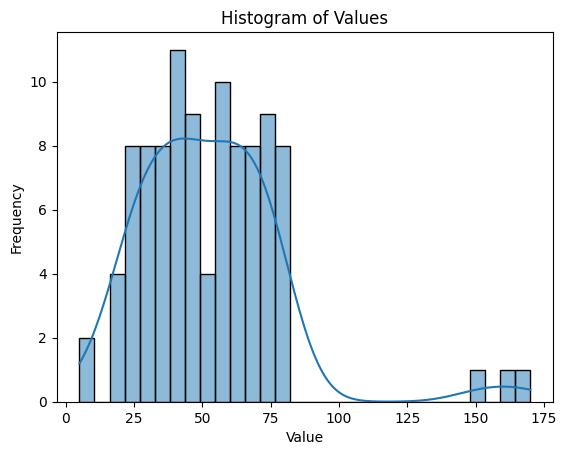

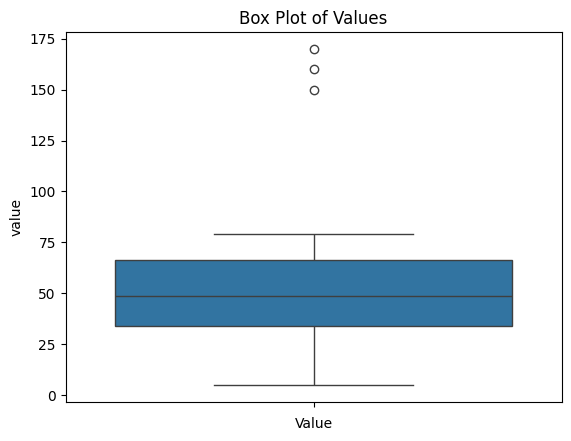

Outliers:
 95    150
96    160
97    170
Name: value, dtype: int64
Category Counts:
 label
C    31
A    28
D    26
B    15
Name: count, dtype: int64


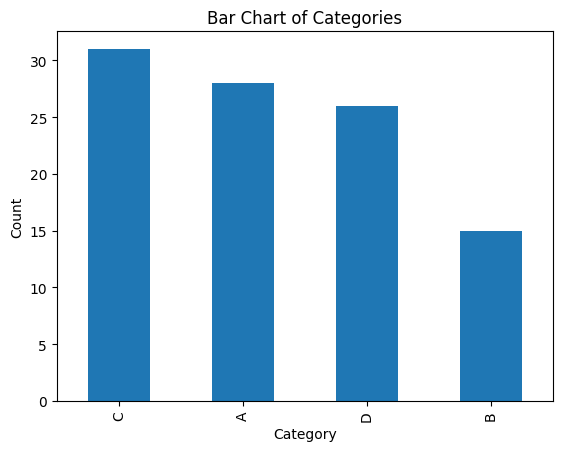

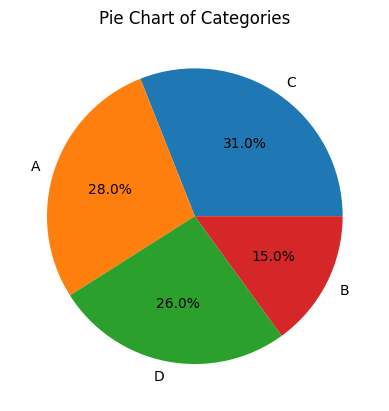

In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create dataset with random values and outliers
np.random.seed(42)
numbers = list(np.random.randint(20, 80, 95)) + [150, 160, 170, 5, 10]
labels = np.random.choice(['A', 'B', 'C', 'D'], size=100)

# Create DataFrame with one numerical and one categorical column
df = pd.DataFrame({'value': numbers, 'label': labels})
print("Sample Data:\n", df.head())

# Select numerical column
num_col = df['value']

# Compute mean
print("Mean:", num_col.mean())

# Compute median
print("Median:", num_col.median())

# Compute mode
print("Mode:", num_col.mode()[0])

# Compute standard deviation
print("Standard Deviation:", num_col.std())

# Compute variance
print("Variance:", num_col.var())

# Compute range
print("Range:", num_col.max() - num_col.min())

# Plot histogram to visualize distribution
sns.histplot(num_col, bins=30, kde=True)
plt.title("Histogram of Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

# Plot box plot to check for outliers
sns.boxplot(y=num_col)
plt.title("Box Plot of Values")
plt.xlabel("Value")
plt.show()

# Detect outliers using IQR method
q1 = num_col.quantile(0.25)
q3 = num_col.quantile(0.75)
iqr = q3 - q1
outliers = df[(num_col < q1 - 1.5 * iqr) | (num_col > q3 + 1.5 * iqr)]
print("Outliers:\n", outliers['value'])

# Count values in categorical column
counts = df['label'].value_counts()
print("Category Counts:\n", counts)

# Plot bar chart of categorical data
counts.plot(kind='bar', title='Bar Chart of Categories')
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

# Plot pie chart of categorical data
counts.plot(kind='pie', autopct='%1.1f%%', title='Pie Chart of Categories')
plt.ylabel("")
plt.show()


2.	Develop a program to Load a dataset with at least two numerical columns (e.g, Iris, Titanic), Plot a scatter plot of two variables and calculate their Pearson  correlation coefficient. Write a program to compute the covariance and correlation matrix for a dataset. Visualize the correlation matrix using a heatmap to know which variables have strong Positive/negative
correlations


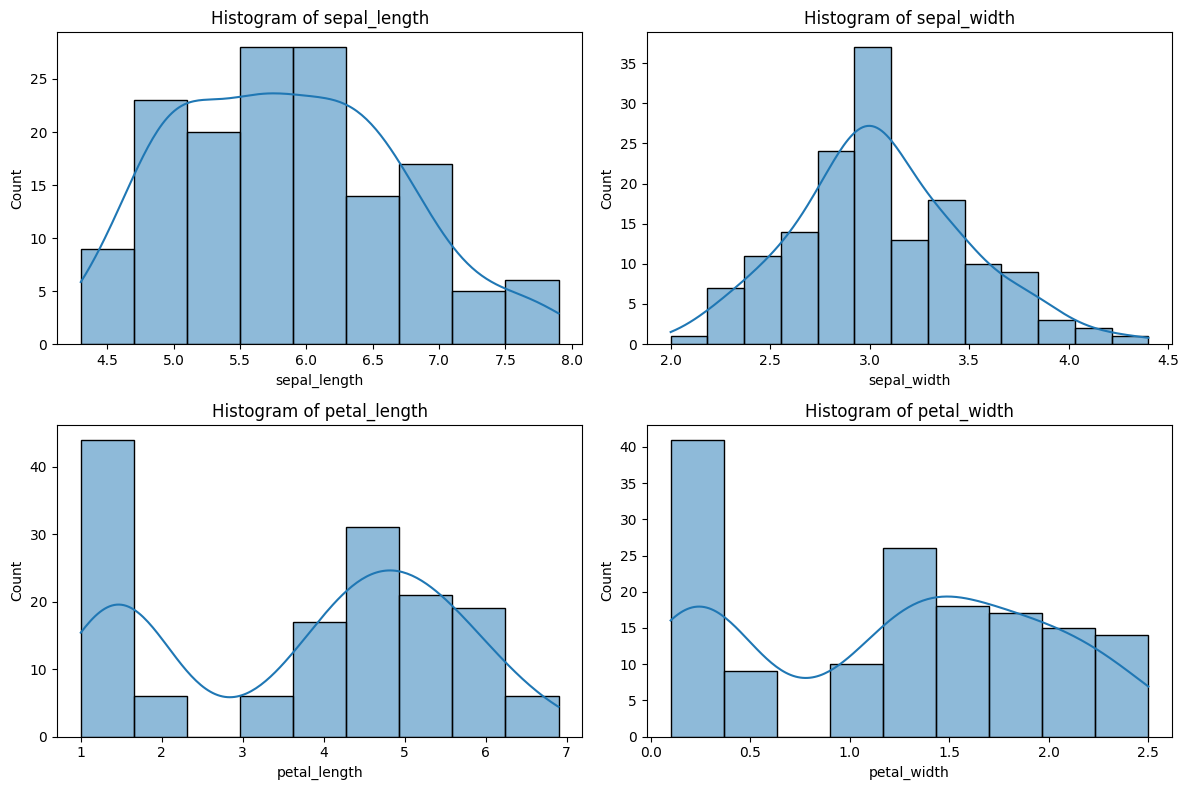

Correlation Matrix:
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


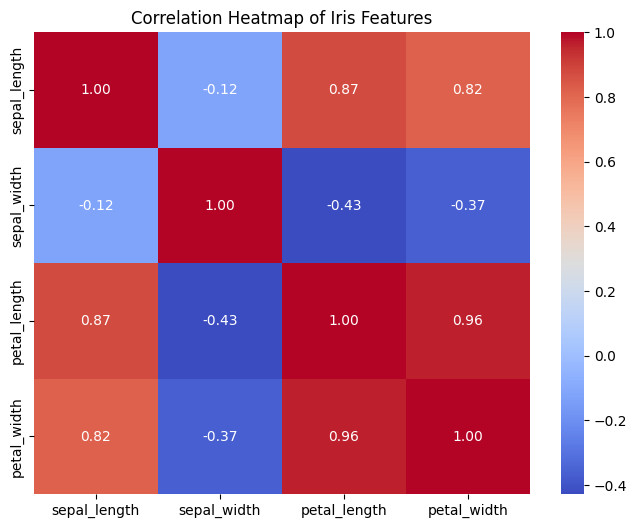

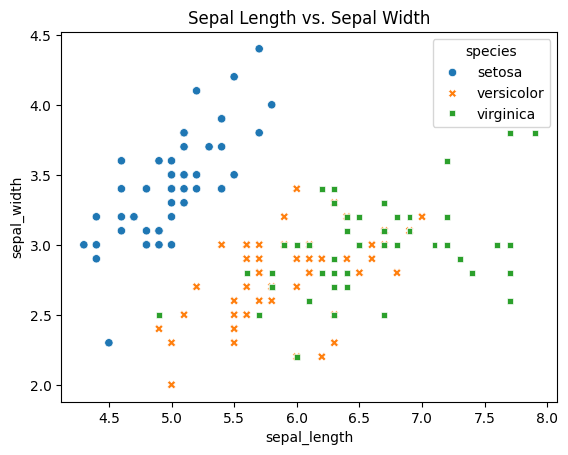

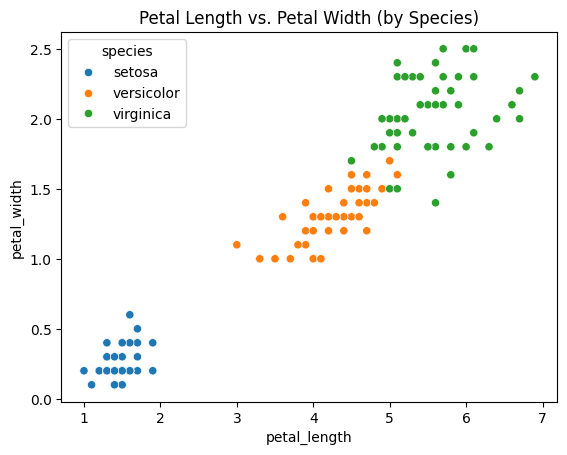

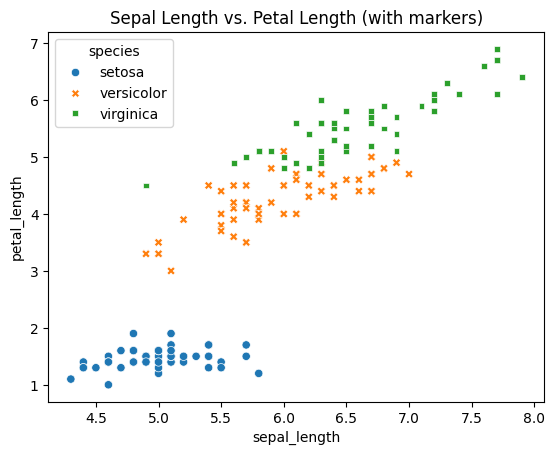

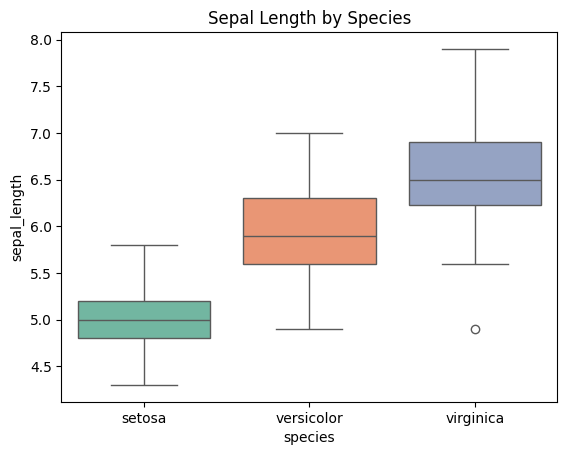

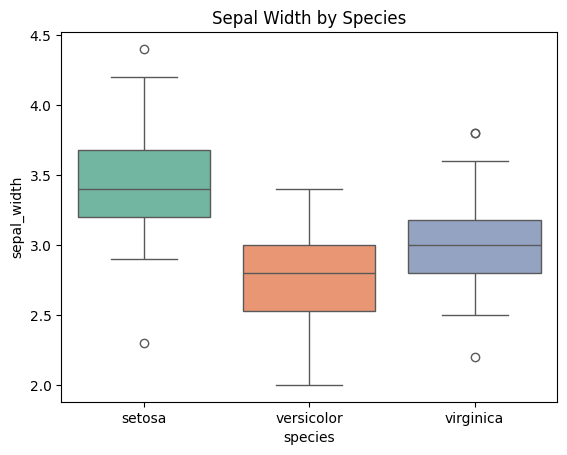

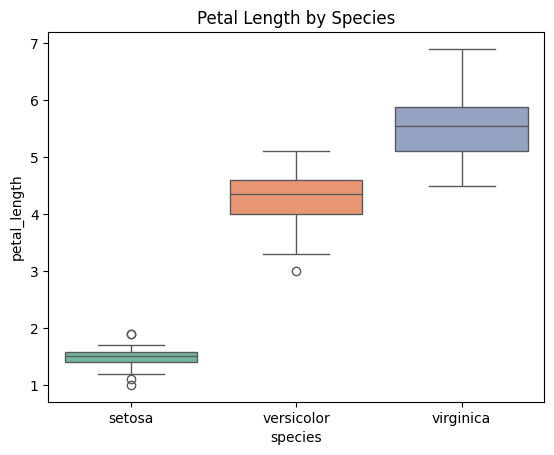

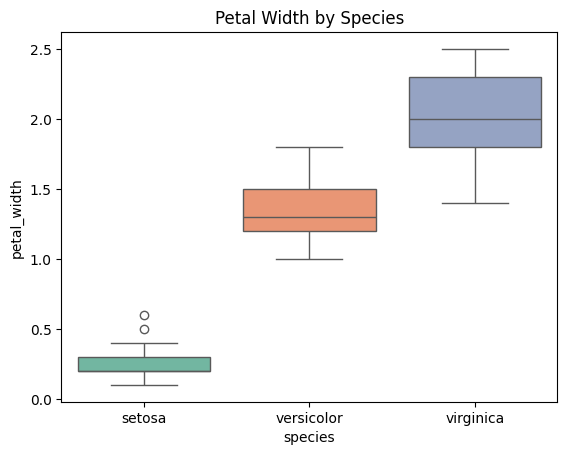

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load the Iris dataset
iris = sns.load_dataset('iris')

# Create histograms for all numerical features
numerical_features = iris.select_dtypes(include=['number']).columns
plt.figure(figsize=(12, 8))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)  # Create 2x2 subplots
    sns.histplot(iris[feature], kde=True)  # Plot histogram with density
    plt.title(f'Histogram of {feature}')
plt.tight_layout()
plt.show()

# Calculate Pearson correlation coefficient between the two variables
pearson_corr = x.corr(y)
print(f"Pearson correlation coefficient (sepal_length vs sepal_width): {pearson_corr:.3f}")

# Calculate correlation matrix (excluding species column)
correlation_matrix = iris.drop('species', axis=1).corr(method='pearson')
print("Correlation Matrix:\n", correlation_matrix)

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')  # Annotated heatmap
plt.title('Correlation Heatmap of Iris Features')
plt.show()

# Scatter plot: Sepal Length vs Sepal Width
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', style='species', data=iris)
plt.title('Sepal Length vs. Sepal Width')
plt.show()

# Scatter plot: Petal Length vs Petal Width
sns.scatterplot(x='petal_length', y='petal_width', hue='species', data=iris)
plt.title('Petal Length vs. Petal Width (by Species)')
plt.show()

# Scatter plot: Sepal Length vs Petal Length with style
sns.scatterplot(x='sepal_length', y='petal_length', hue='species', style='species', data=iris)
plt.title('Sepal Length vs. Petal Length (with markers)')
plt.show()

# Boxplot: Sepal Length grouped by species with color
sns.boxplot(x='species', y='sepal_length', data=iris, palette='Set2')
plt.title('Sepal Length by Species')
plt.show()

# Boxplot: Sepal Width grouped by species with color
sns.boxplot(x='species', y='sepal_width', data=iris, palette='Set2')
plt.title('Sepal Width by Species')
plt.show()

# Boxplot: Petal Length grouped by species with color
sns.boxplot(x='species', y='petal_length', data=iris, palette='Set2')
plt.title('Petal Length by Species')
plt.show()

# Boxplot: Petal Width grouped by species with color
sns.boxplot(x='species', y='petal_width', data=iris, palette='Set2')
plt.title('Petal Width by Species')
plt.show()


3.	Develop a program to Load a dataset with at least two numerical columns (e.g., Iris). Plot a Histogram and correlation heatmap of Iris features .



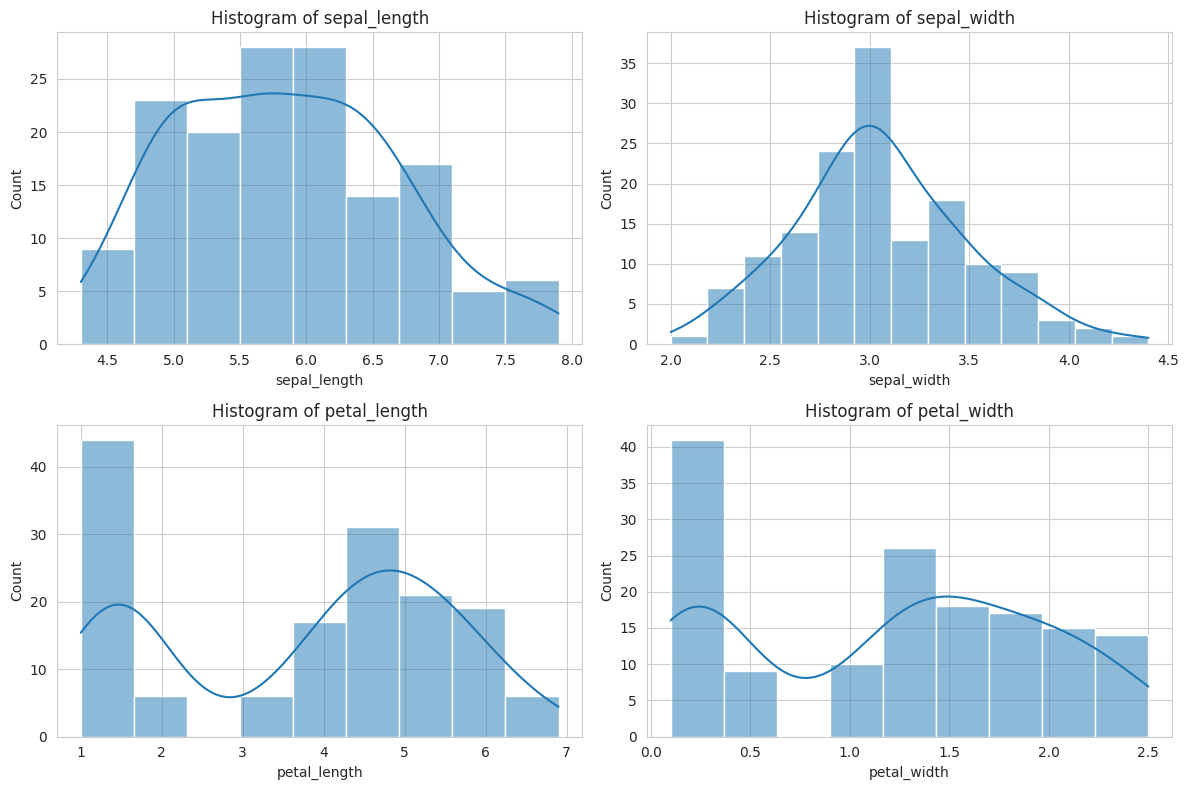

Correlation Matrix:
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


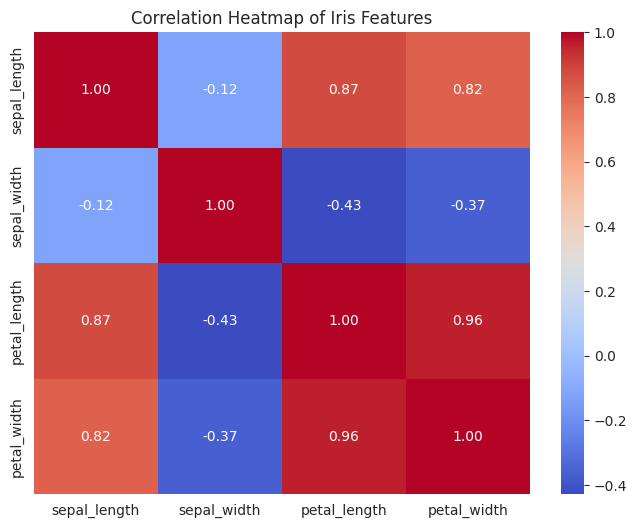

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Load the Iris dataset
df = sns.load_dataset('iris')

# Save to CSV (optional)
df.to_csv('Iris.csv', index=False)

# Plot histograms for numerical features
numerical_features = df.select_dtypes(include=['number']).columns
plt.figure(figsize=(12, 8))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Histogram of {feature}')
plt.tight_layout()
plt.show()

# Calculate correlation matrix of numerical features
corr_matrix = df[numerical_features].corr()

# Print correlation matrix
print("Correlation Matrix:\n", corr_matrix)

# Plot heatmap of correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Iris Features')
plt.show()


4.	Develop a program to Load a dataset with at least two numerical columns (e.g., Iris). Plot a scatter plot and   box plot of Iris features.


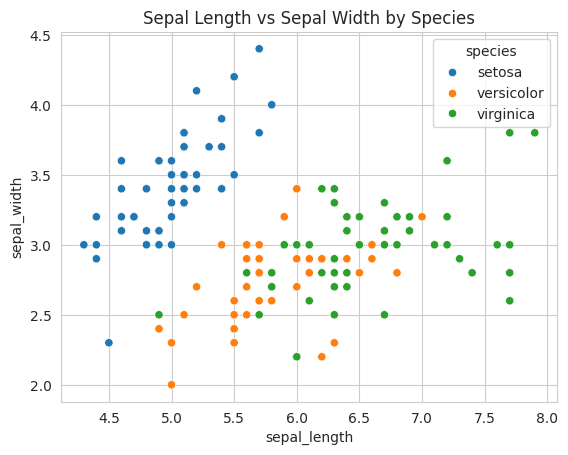

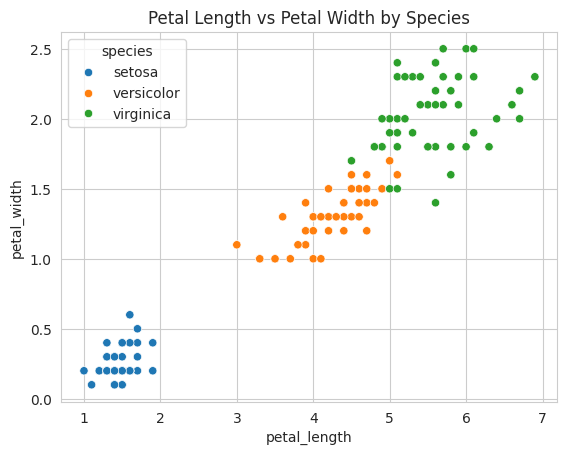

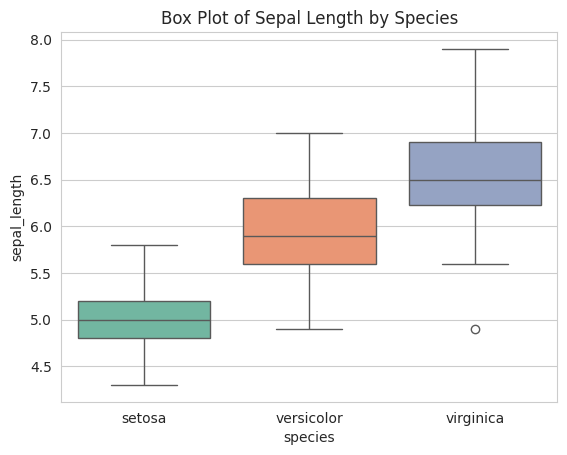

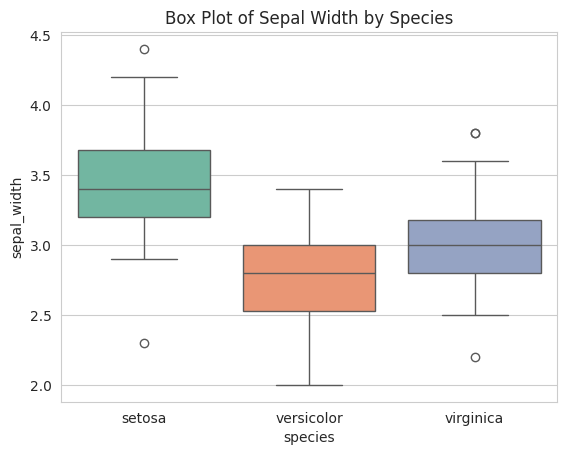

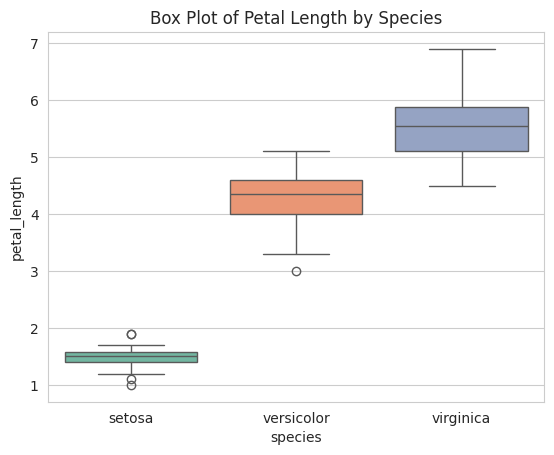

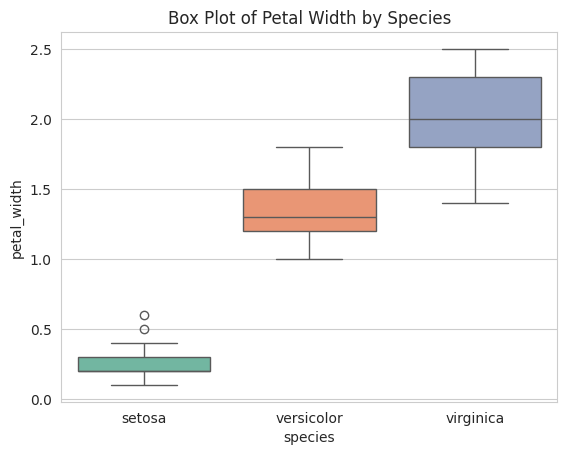

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Load the Iris dataset
df = sns.load_dataset('iris')

# Scatter plot: Sepal Length vs Sepal Width colored by species
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=df)
plt.title('Sepal Length vs Sepal Width by Species')
plt.show()

# Scatter plot: Petal Length vs Petal Width colored by species
sns.scatterplot(x='petal_length', y='petal_width', hue='species', data=df)
plt.title('Petal Length vs Petal Width by Species')
plt.show()

# Box plot: Sepal Length grouped by species
sns.boxplot(x='species', y='sepal_length', data=df, palette='Set2')
plt.title('Box Plot of Sepal Length by Species')
plt.show()

# Box plot: Sepal Width grouped by species
sns.boxplot(x='species', y='sepal_width', data=df, palette='Set2')
plt.title('Box Plot of Sepal Width by Species')
plt.show()

# Box plot: Petal Length grouped by species
sns.boxplot(x='species', y='petal_length', data=df, palette='Set2')
plt.title('Box Plot of Petal Length by Species')
plt.show()

# Box plot: Petal Width grouped by species
sns.boxplot(x='species', y='petal_width', data=df, palette='Set2')
plt.title('Box Plot of Petal Width by Species')
plt.show()

5.	Develop a program to implement Principal Component Analysis (PCA) for reducing the dimensionality of the Iris dataset from 4 features to 2.



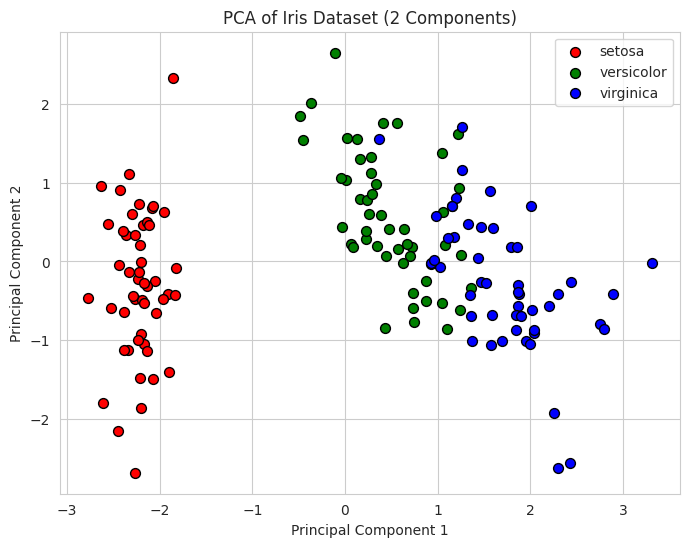

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Load Iris dataset
iris = datasets.load_iris()
X = iris.data  # Features
y = iris.target  # Labels
target_names = iris.target_names

# Standardize the features (mean=0, variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate covariance matrix
cov_matrix = np.cov(X_scaled.T)

# Calculate eigenvalues and eigenvectors of covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues and eigenvectors in descending order
idxs = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idxs]
eigenvectors = eigenvectors[:, idxs]

# Select top 2 eigenvectors (principal components)
n_components = 2
principal_components = eigenvectors[:, :n_components]

# Project data onto principal components
X_reduced = np.dot(X_scaled, principal_components)

# Plot the reduced data
plt.figure(figsize=(8, 6))
colors = ['r', 'g', 'b']

for i, color in enumerate(colors):
    plt.scatter(
        X_reduced[y == i, 0], X_reduced[y == i, 1],
        c=color, label=target_names[i], edgecolor='k', s=50
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset (2 Components)')
plt.legend()
plt.grid(True)
plt.show()


6.	Develop a program to load the Iris dataset. Implement the k-Nearest Neighbors (k-NN) algorithm for classifying flowers based on their features. Split the dataset into training and testing sets and evaluate the model using metrics like accuracy and F1-score. Test it for different values of 𝑘 (e.g., k=1,3,5) and evaluate the accuracy.



In [16]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Labels

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Function to test k-NN for different values of k
def test_knn(k_values):
    for k in k_values:
        # Create k-NN classifier with current k
        knn = KNeighborsClassifier(n_neighbors=k)
        # Train the classifier
        knn.fit(X_train, y_train)
        # Predict on test data
        y_pred = knn.predict(X_test)
        # Calculate accuracy and F1-score (weighted for class imbalance)
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        # Print results
        print(f"Results for k={k}:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1-score: {f1:.4f}")
        print("-" * 40)

# List of k values to test
k_values = [1, 3, 5]

# Run the test
test_knn(k_values)


Results for k=1:
Accuracy: 1.0000
F1-score: 1.0000
----------------------------------------
Results for k=3:
Accuracy: 1.0000
F1-score: 1.0000
----------------------------------------
Results for k=5:
Accuracy: 1.0000
F1-score: 1.0000
----------------------------------------


7.	Implement the non-parametric Locally Weighted Regression algorithm in order to fit data points. Select appropriate data set for your experiment and draw graphs.



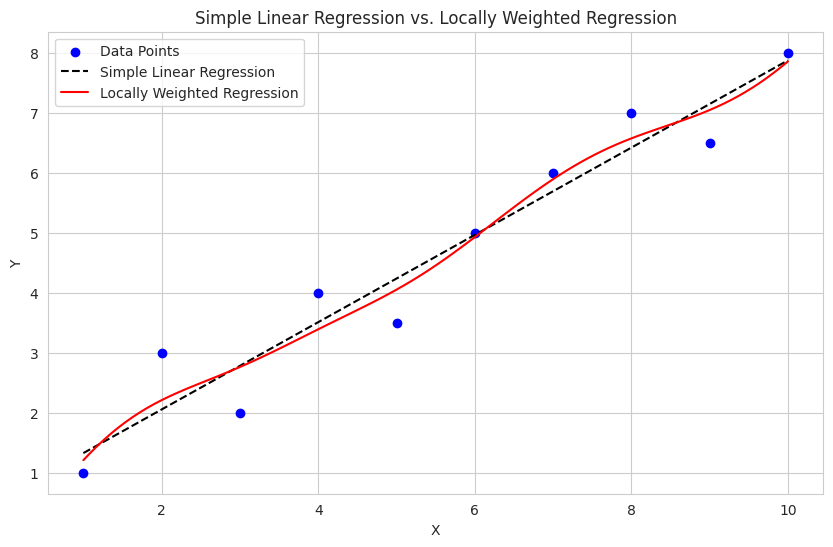

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Gaussian kernel function to compute weights based on distance
def gaussian_kernel(x, x_query, tau):
    return np.exp(-((x - x_query) ** 2) / (2 * tau ** 2))

# Locally Weighted Regression function
def locally_weighted_regression(X, y, x_query, tau):
    # Add bias term (intercept) to X
    X_b = np.c_[np.ones(len(X)), X]
    # Query point with bias term
    x_query_b = np.array([1, x_query])
    # Compute weights matrix W for each point based on the kernel
    W = np.diag(gaussian_kernel(X, x_query, tau))
    # Calculate theta = (X^T W X)^-1 X^T W y
    theta = np.linalg.inv(X_b.T @ W @ X_b) @ X_b.T @ W @ y
    # Predict the value at x_query
    return x_query_b @ theta

# Dataset (simple nonlinear data)
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y = np.array([1, 3, 2, 4, 3.5, 5, 6, 7, 6.5, 8])

# Points where predictions are required
X_query = np.linspace(1, 10, 100)

# Bandwidth parameter controlling locality (smoothing)
tau = 1.0

# Compute LWR predictions for each query point
y_lwr = np.array([locally_weighted_regression(X, y, x_q, tau) for x_q in X_query])

# Fit simple linear regression for comparison
lin_reg = LinearRegression()
X_reshaped = X.reshape(-1, 1)
lin_reg.fit(X_reshaped, y)
y_lin = lin_reg.predict(X_query.reshape(-1, 1))

# Plot original data, linear regression, and LWR curve
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X_query, y_lin, color='black', linestyle='dashed', label='Simple Linear Regression')
plt.plot(X_query, y_lwr, color='red', label='Locally Weighted Regression')
plt.title("Simple Linear Regression vs. Locally Weighted Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()


8.	Develop a program to demonstrate the working of Linear Regression



Mean Squared Error: 0.9178
Intercept (b0): 4.2063
Coefficient (b1): 2.9805


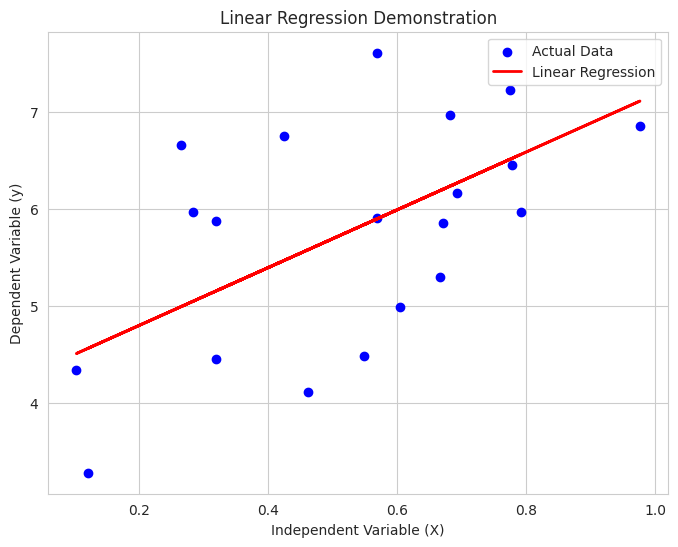

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. Generate Sample Data
np.random.seed(0)  # for reproducibility
X = np.random.rand(100, 1)  # Independent variable (feature)
y = 4 + 3 * X + np.random.randn(100, 1)  # Dependent variable with noise

# 2. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# test_size=0.2 means 20% test data; random_state ensures reproducibility

# 3. Create a Linear Regression Model
model = LinearRegression()

# 4. Train the Model
model.fit(X_train, y_train)
# fit() finds the best fitting line parameters (slope and intercept)

# 5. Make Predictions on the Test Set
y_pred = model.predict(X_test)
# predict() uses the learned model to predict on new data

# 6. Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"Intercept (b0): {model.intercept_[0]:.4f}")
print(f"Coefficient (b1): {model.coef_[0][0]:.4f}")

# 7. Visualize the Results
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')  # Actual test data points
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Linear Regression')  # Regression line
plt.xlabel("Independent Variable (X)")
plt.ylabel("Dependent Variable (y)")
plt.title("Linear Regression Demonstration")
plt.legend()
plt.grid(True)
plt.show()


9.	Develop a program to demonstrate the working of Polynomial Regression



Mean Squared Error (Polynomial Regression Degree 2): 0.6989
Intercept (b0): 2.056499867939385
Coefficients (b1, b2, ...): [[0.         0.92493944 0.52420328]]


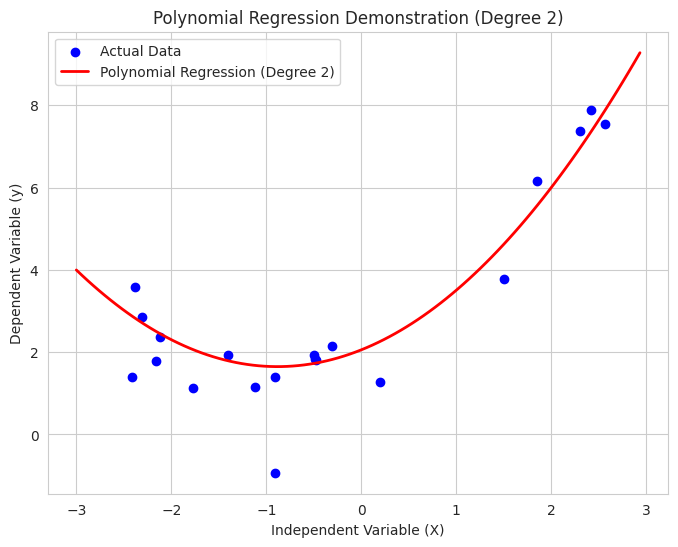

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. Generate Sample Non-Linear Data
np.random.seed(1)
X = 6 * np.random.rand(100, 1) - 3  # Random values between -3 and 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)  # Quadratic relationship with noise

# 2. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define the Degree of the Polynomial
poly_degree = 2  # 2nd degree polynomial (quadratic)

# 4. Create Polynomial Features
poly_features = PolynomialFeatures(degree=poly_degree)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)
# This converts features to [1, x, x^2]

# 5. Create and Train a Linear Regression Model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# 6. Make Predictions on the Test Set
y_pred_poly = model.predict(X_test_poly)

# 7. Evaluate the Model
mse_poly = mean_squared_error(y_test, y_pred_poly)
print(f"Mean Squared Error (Polynomial Regression Degree {poly_degree}): {mse_poly:.4f}")
print("Intercept (b0):", model.intercept_[0])
print("Coefficients (b1, b2, ...):", model.coef_)

# 8. Visualize the Results
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')

# Generate points for plotting the regression curve
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_plot_poly = poly_features.transform(X_plot)
y_plot_pred = model.predict(X_plot_poly)

plt.plot(X_plot, y_plot_pred, color='red', linewidth=2,
         label=f'Polynomial Regression (Degree {poly_degree})')

plt.xlabel("Independent Variable (X)")
plt.ylabel("Dependent Variable (y)")
plt.title(f"Polynomial Regression Demonstration (Degree {poly_degree})")
plt.legend()
plt.grid(True)
plt.show()


10.	Develop a program to load the Titanic dataset. Split the data into training and test sets. Train a decision tree classifier. Visualize the tree structure. Evaluate accuracy, precision, recall, and F1-score.



Accuracy: 0.7063
Precision: 0.7234
Recall: 0.5397
F1-score: 0.6182

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.84      0.76        80
           1       0.72      0.54      0.62        63

    accuracy                           0.71       143
   macro avg       0.71      0.69      0.69       143
weighted avg       0.71      0.71      0.70       143



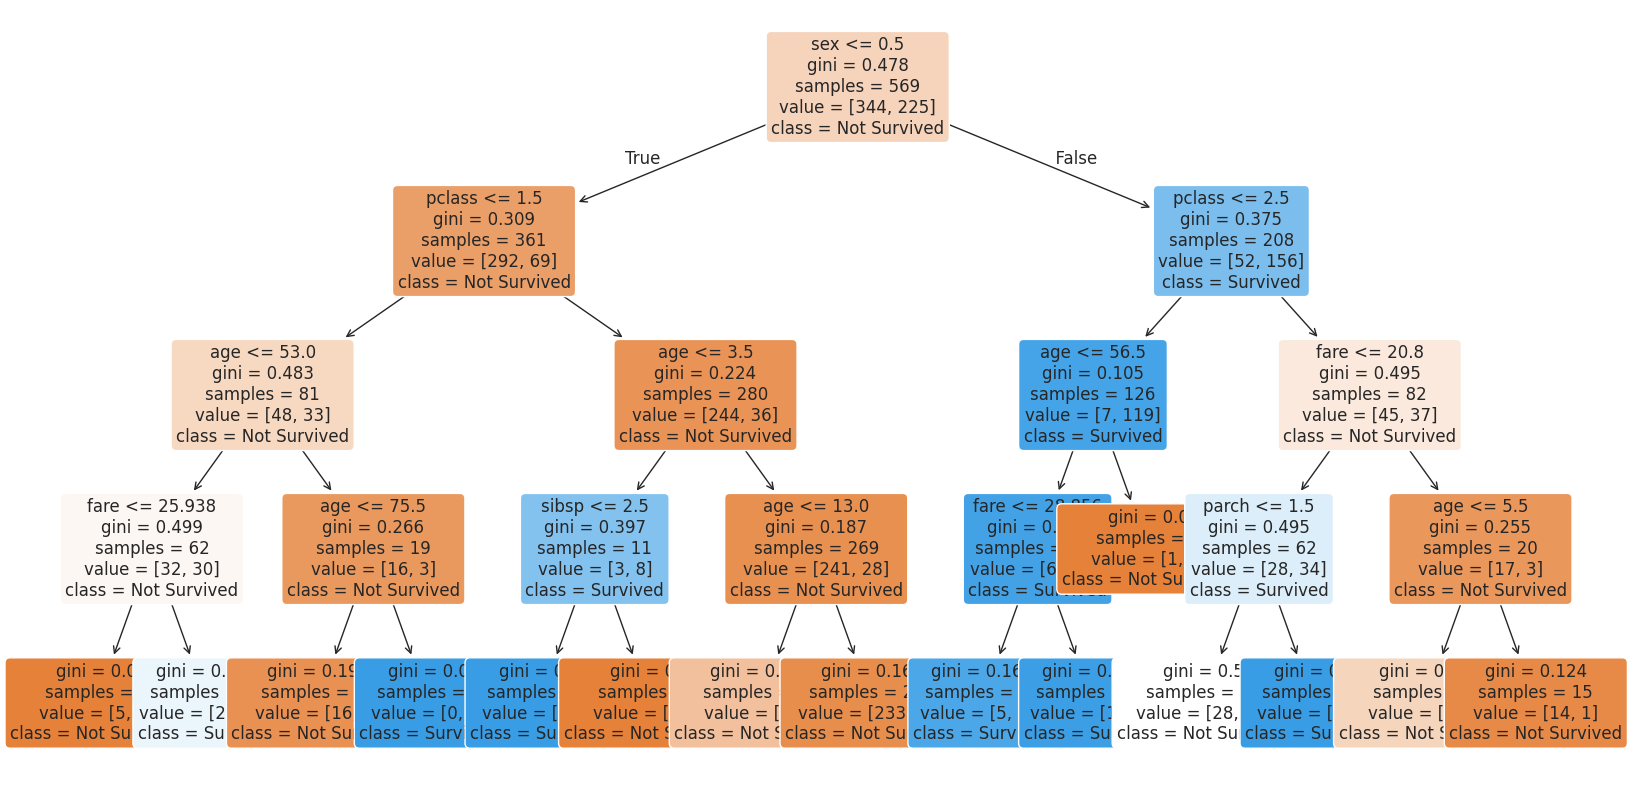

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Load Titanic dataset from seaborn
titanic = sns.load_dataset('titanic')

# Basic preprocessing: drop rows with missing values in critical columns
titanic.dropna(subset=['age', 'embarked', 'sex'], inplace=True)

# Encode categorical variables
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['embarked'] = titanic['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Select features and target
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = titanic[features]
y = titanic['survived']

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42, max_depth=4)
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)

# Evaluate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))

# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=features, class_names=['Not Survived', 'Survived'], filled=True, rounded=True, fontsize=12)
plt.show()


11.	Develop a program to implement the Naive Bayesian classifier considering Iris dataset for training. Compute the accuracy of the classifier, considering the test data.



In [21]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Load Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Initialize Gaussian Naive Bayes classifier
gnb = GaussianNB()

# Train the model
gnb.fit(X_train, y_train)

# Predict on test data
y_pred = gnb.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Accuracy: 1.0000

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



12.	Develop a program to implement k-means clustering using Wisconsin Breast Cancer data set and visualize the clustering result.



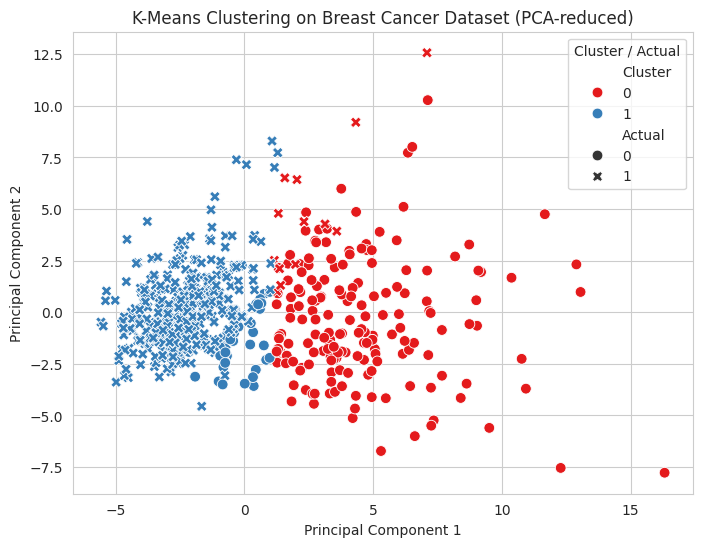

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')

# Load Wisconsin Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans clustering (2 clusters)
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Reduce dimensions for visualization (PCA to 2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for easy plotting
df = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Cluster': clusters,
    'Actual': y
})

# Plot clustering results
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', style='Actual', palette='Set1', s=60)
plt.title('K-Means Clustering on Breast Cancer Dataset (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster / Actual', loc='best')
plt.show()
